In [ ]:
# 1. Import required libraries and set up HANA Cloud connection
from hana_ml import dataframe
import pandas as pd
import numpy as np
from hana_ml.dataframe import ConnectionContext
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from hana_ai.tools.hana_ml_tools.pfn_data_gen import pfn_prior_data_gen

# Connect to SAP HANA Cloud
cc = dataframe.ConnectionContext(
    "6291b51a-ea33-4ade-bb5c-0b8f1a032b9d.hana.demo-hc-3-hna0-hc-dev.dev-aws.hanacloud.ondemand.com",
    user="None",
    password="Abcd1234",
    port=443,
)

In [ ]:
# 2. Generate dynamic synthetic data
graph, df = pfn_prior_data_gen(
    num_features=6,           # Number of features for diabetes dataset
    num_samples=100,          # Number of samples
    task_type="classification"  # Classification task for diabetes
)
# Neu
df["INDEX"] = range(len(df))
# Neu Ende

print("First rows of generated DataFrame:")
print(df.head())

First rows of generated DataFrame:
   V1       V25       V38       V31       V37       V10       V26       V13  \
0   5 -0.572483  0.394947 -0.083600 -0.247800 -0.695402 -0.400038  0.213479   
1  10  0.725788 -0.885067  0.526422 -1.879591  0.248125  0.851959 -1.153663   
2   5 -1.639525 -0.610096  0.437664  0.352173  0.479693  0.231052 -0.431746   
3   1 -0.524588  0.084608  0.431636 -1.938579 -1.633667 -0.324394  1.158299   
4   2 -0.777373  0.604620 -0.995700  0.517259 -0.183598 -0.942744  0.037682   

        V20        V7        V4       V21 V0  INDEX  
0  0.115496 -0.474737  3.696774 -0.871980  0      0  
1  0.023358 -0.033050  2.219304  0.134102  0      1  
2  1.051577 -0.067299  2.975587 -0.684630  1      2  
3  0.125441  0.271823  2.732187 -0.157244  0      3  
4  0.632788  0.243425  1.243659 -0.785429  1      4  


In [ ]:
# 3. Save synthetic data to HANA Cloud
from hana_ml.dataframe import create_dataframe_from_pandas
hana_df = create_dataframe_from_pandas(
    connection_context=cc,
    pandas_df=df,
    table_name='GENERATED_DATA_TBL',
    force=True
)

100%|██████████| 1/1 [00:00<00:00,  2.92it/s]


In [ ]:
# 4. Load data from HANA table and define features/target
hana_table = cc.table('GENERATED_DATA_TBL')
hana_columns = hana_table.columns
print("Columns in HANA:", hana_columns)
print("Columns in DataFrame:", list(df.columns))

target = 'V0'
#features = [col for col in hana_columns if col != target and col in df.columns]
features = [col for col in hana_columns if col not in [target, "INDEX"] and col in df.columns]
print("Used features:", features)

X = df[features].values
y = df[target].values

Columns in HANA: ['V1', 'V25', 'V38', 'V31', 'V37', 'V10', 'V26', 'V13', 'V20', 'V7', 'V4', 'V21', 'V0', 'INDEX']
Columns in DataFrame: ['V1', 'V25', 'V38', 'V31', 'V37', 'V10', 'V26', 'V13', 'V20', 'V7', 'V4', 'V21', 'V0', 'INDEX']
Used features: ['V1', 'V25', 'V38', 'V31', 'V37', 'V10', 'V26', 'V13', 'V20', 'V7', 'V4', 'V21']


In [ ]:
# 5. Preprocessing pipeline for numeric features
X_df = df[features].copy()
X_df = X_df.replace({pd.NA: np.nan})  # Convert pd.NA to np.nan if necessary

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('variance', VarianceThreshold(threshold=0.01))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X_df)

In [ ]:
# 6. Show data before and after preprocessing
print("Data before preprocessing:")
print(X[:5])
print("Data after preprocessing:")
print(X_preprocessed[:5])

Data before preprocessing:
[[ 5.         -0.57248271  0.39494717 -0.08359963 -0.24780031 -0.69540167
  -0.40003777  0.21347922  0.11549594 -0.47473681  3.69677448 -0.87197971]
 [10.          0.72578776 -0.88506722  0.52642155 -1.87959075  0.24812528
   0.85195911 -1.1536634   0.0233575  -0.03305018  2.21930361  0.13410169]
 [ 5.         -1.63952541 -0.61009568  0.43766448  0.35217261  0.47969294
   0.23105186 -0.43174592  1.05157709 -0.06729911  2.97558713 -0.68463022]
 [ 1.         -0.52458787  0.08460788  0.43163621 -1.93857861 -1.63366652
  -0.32439366  1.15829933  0.12544055  0.27182287  2.73218679 -0.15724352]
 [ 2.         -0.7773726   0.60462046 -0.99570042  0.51725888 -0.18359773
  -0.94274437  0.03768222  0.63278836  0.24342482  1.24365902 -0.78542882]]
Data after preprocessing:
[[0.5        0.31674774 0.61661369 0.42502897 0.54274479 0.42740189
  0.51049297 0.53826739 0.15116438 0.03799814 0.98438749 0.30447835]
 [1.         0.70213461 0.40730678 0.56590756 0.09746051 0.58218

In [ ]:
# 7. Train-test split
X_train_preprocessed, X_test_preprocessed, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

In [ ]:
# 8. Import and initialize HGBTree tool
from hana_ai.tools.hana_ml_tools.hybridgradientboosting_tools import HGBTreeFitAndSave
hgb_tool = HGBTreeFitAndSave(cc)

In [ ]:
# 9. Train the Hybrid Gradient Boosting model
hgb_tool.run(tool_input={
    "name": "my_hgbtree_model",
    "version": "1",
    "fit_table": "GENERATED_DATA_TBL",
    "target": target,
    "features": features,
    "max_depth": 12,
    "n_estimators": 500,
    "learning_rate": 0.005,
    "subsample": 0.9,
    "min_samples_leaf": 4,
    "col_subsample_tree": 0.7,
    "random_state": 42,
    "calculate_importance": True,
    "thread_ratio": 0.5,
    "compression": True,
    "key": "INDEX"  # <--- NEU: Index-Spalte für Grid Search/Score
})

'{"status": "success", "model_name": "my_hgbtree_model", "model_version": 1, "trained_table": "GENERATED_DATA_TBL"}'

In [10]:
# 10. Import and initialize prediction tool
from hana_ai.tools.hana_ml_tools.hybridgradientboosting_tools import HGBTreeLoadModelAndPredict
hgb_predict_tool = HGBTreeLoadModelAndPredict(cc)

   INDEX SCORE  CONFIDENCE                                        REASON_CODE
0      0     0    0.781954  [{"attr":"V25","val":0.3684972326564396,"pct":...
1      1     0    0.867223  [{"attr":"V1","val":-0.5005116501581086,"pct":...
2      2     1    0.671472  [{"attr":"V25","val":0.5855364076295155,"pct":...
3      3     0    0.723478  [{"attr":"V1","val":-0.3173682118830827,"pct":...
4      4     1    0.712092  [{"attr":"V1","val":0.48670655322203446,"pct":...
y_test shape: (20,)
y_pred shape: (100,)


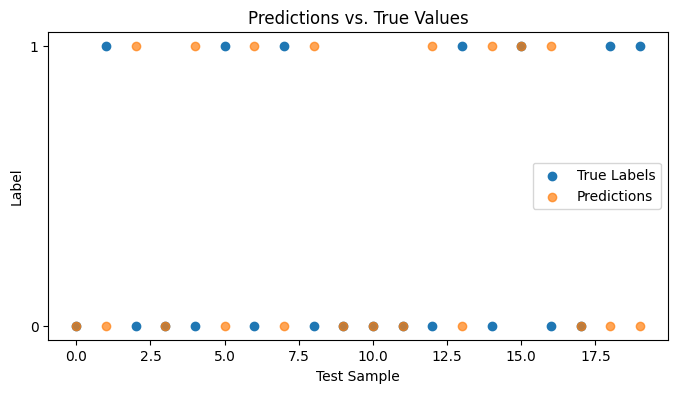

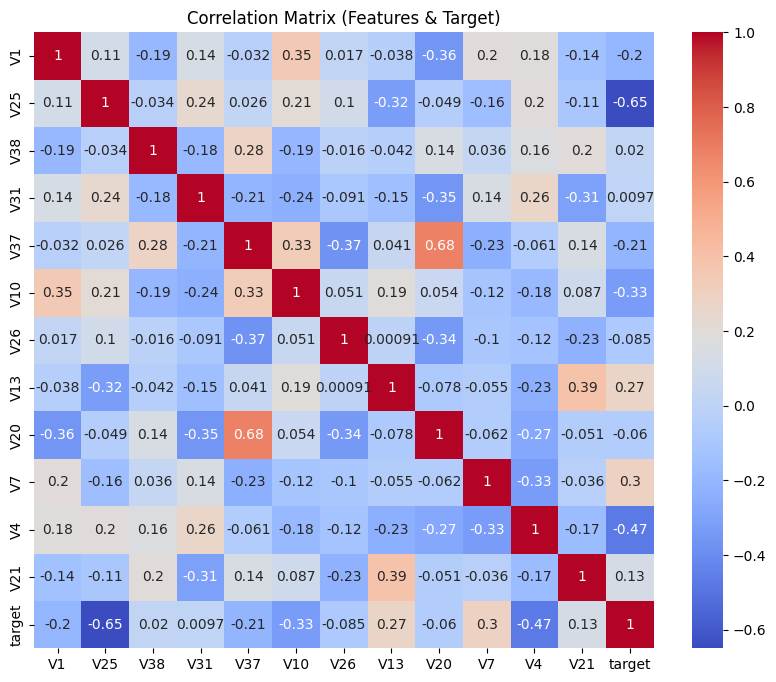

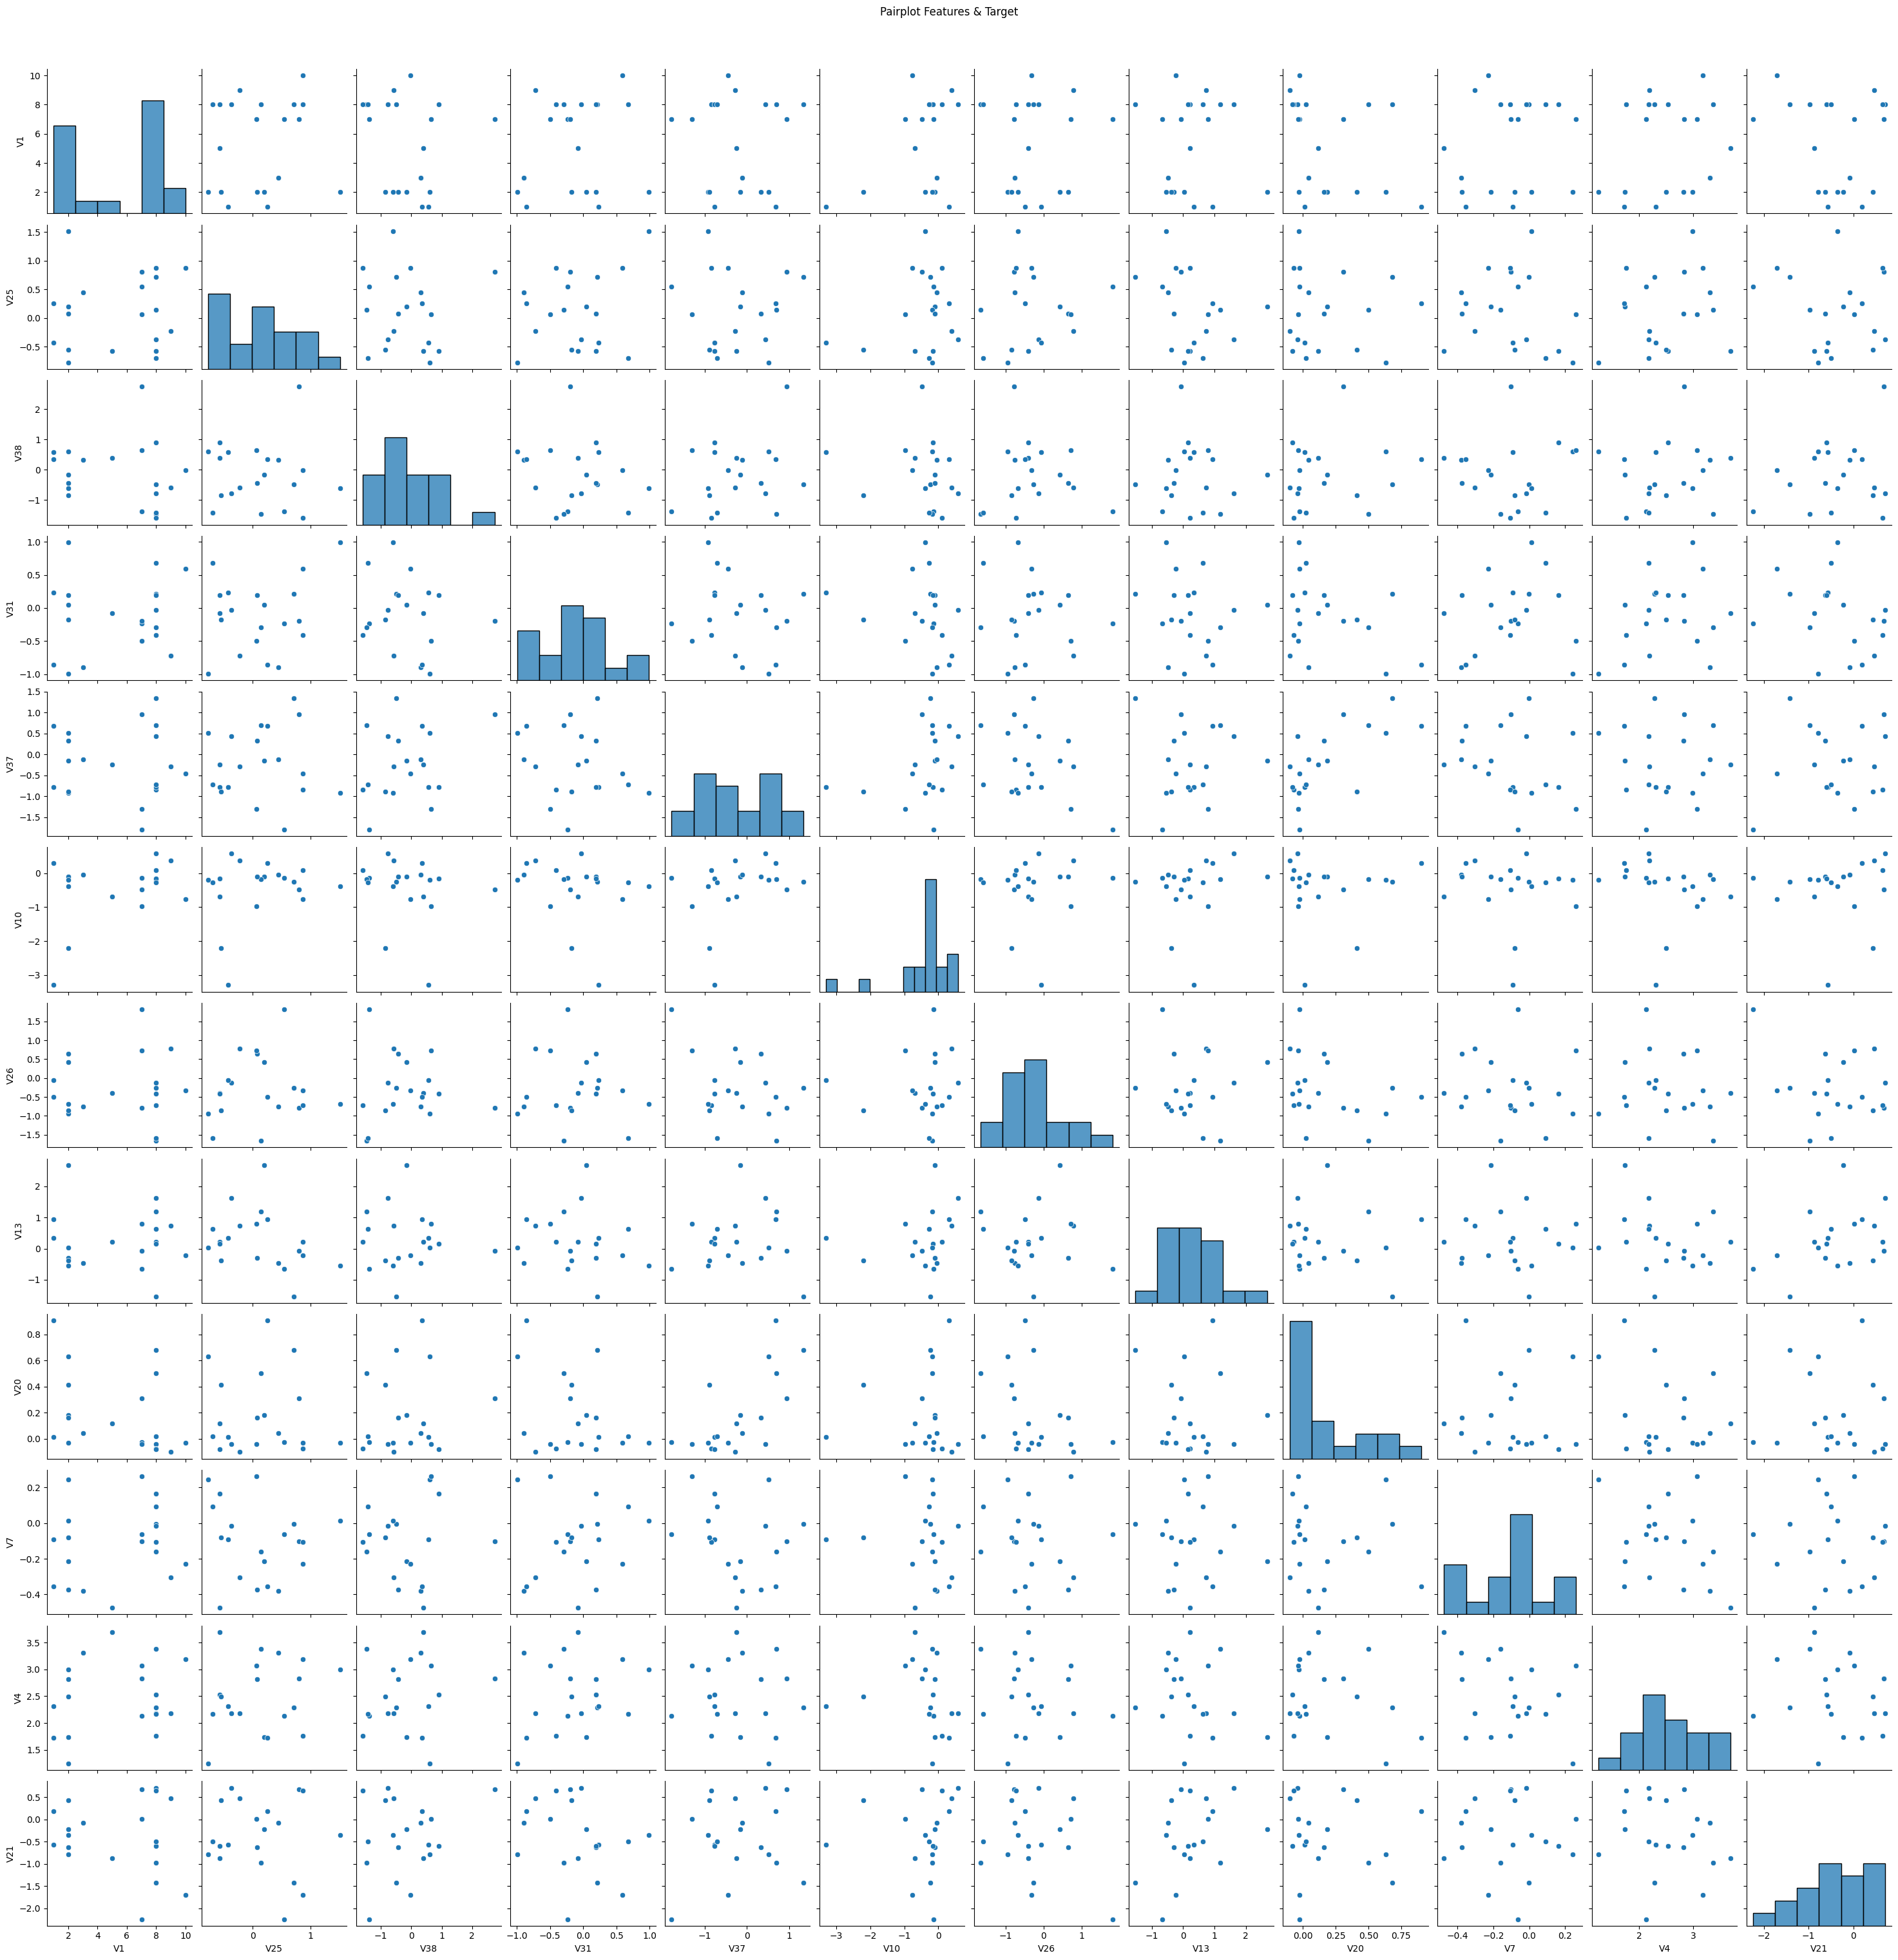

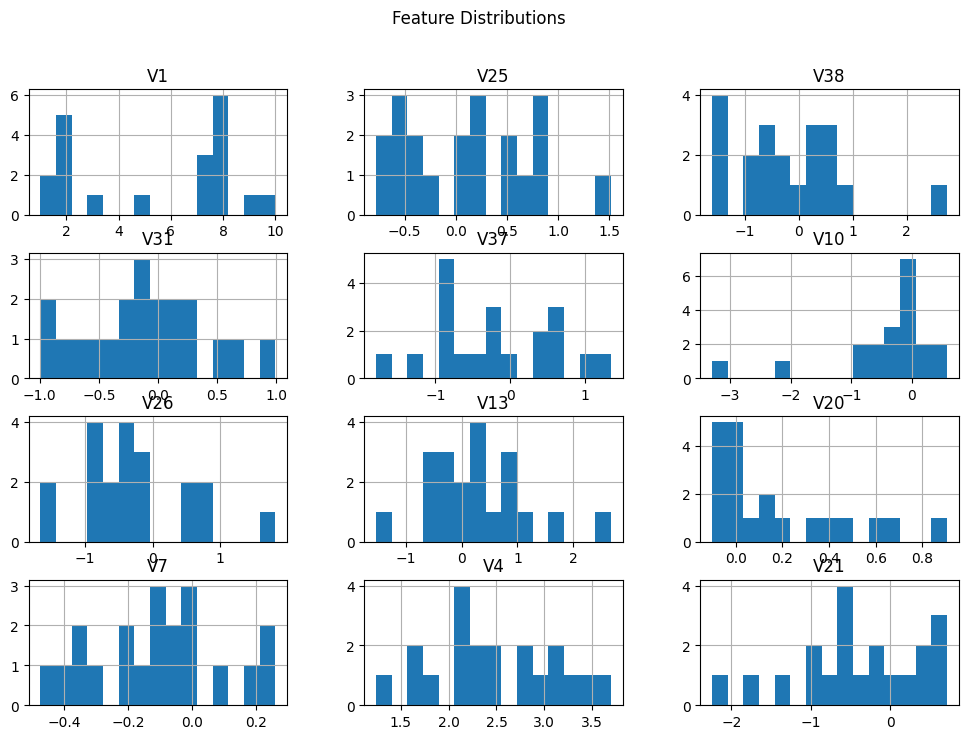

In [11]:
# Postprocessing after prediction (Analysis & Visualization)
# This cell focuses on model evaluation and data understanding.
import numpy as np

# Ensure X_test_preprocessed is a numpy array
if not isinstance(X_test_preprocessed, np.ndarray):
    X_test_preprocessed = np.array(X_test_preprocessed)

# Run prediction tool to get model outputs
predictions = hgb_predict_tool.run(tool_input={
    "name": "my_hgbtree_model",
    "version": "1",
    "predict_table": "GENERATED_DATA_TBL",
    "features": features,
    "X_test": X_test_preprocessed,
    "key": "INDEX"
})

# Inverse transform test data to original scale
scaler = preprocessor.named_transformers_['num'].named_steps['scaler']
X_test_original = scaler.inverse_transform(X_test_preprocessed)

# Convert predictions output to dict if necessary
import json
if isinstance(predictions, str):
    predictions_dict = json.loads(predictions)
else:
    predictions_dict = predictions

# Load prediction results from HANA Cloud
pred_df = pd.DataFrame(predictions_dict["predictions"])
print(pred_df.head())  # Check column names

# Extract prediction values from correct column
if 'SCORE' in pred_df.columns:
    y_pred = pred_df['SCORE'].values
elif 'PREDICTION' in pred_df.columns:
    y_pred = pred_df['PREDICTION'].values
else:
    raise ValueError("Prediction column not found!")

# Only plot if lengths match
print("y_test shape:", np.shape(y_test))
print("y_pred shape:", np.shape(y_pred))

min_len = min(len(y_test), len(y_pred))
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.scatter(range(min_len), y_test[:min_len], label='True Labels')
plt.scatter(range(min_len), y_pred[:min_len], label='Predictions', alpha=0.7)
plt.legend()
plt.title('Predictions vs. True Values')
plt.xlabel('Test Sample')
plt.ylabel('Label')
plt.show()

# --- Additional Visualizations ---

import pandas as pd
import seaborn as sns

# Correlation matrix for features and target
df_corr = pd.DataFrame(X_test_original, columns=features)
df_corr['target'] = y_test[:min_len]
corr_matrix = df_corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Features & Target)')
plt.show()

# Pairplot for features and target
sns.pairplot(df_corr)
plt.suptitle('Pairplot Features & Target', y=1.02)
plt.show()

# Histograms for feature distributions
df_corr.hist(figsize=(12,8), bins=15)
plt.suptitle('Feature Distributions')
plt.show()

   INDEX SCORE  CONFIDENCE                                        REASON_CODE
0      0     0    0.781954  [{"attr":"V25","val":0.3684972326564396,"pct":...
1      1     0    0.867223  [{"attr":"V1","val":-0.5005116501581086,"pct":...
2      2     1    0.671472  [{"attr":"V25","val":0.5855364076295155,"pct":...
3      3     0    0.723478  [{"attr":"V1","val":-0.3173682118830827,"pct":...
4      4     1    0.712092  [{"attr":"V1","val":0.48670655322203446,"pct":...
    V1       V25       V38       V31       V37       V10       V26       V13  \
0  8.0  0.714985 -0.493995  0.214381  1.343752 -0.243603 -0.269433 -1.534878   
1  2.0  0.199485 -0.163454  0.048138 -0.155706 -0.094675  0.427265  2.679534   
2  7.0  0.546133 -1.387887 -0.232299 -1.791418 -0.142232  1.817787 -0.658556   
3  7.0  0.804597  2.739542 -0.193867  0.949363 -0.480600 -0.786340 -0.063826   
4  8.0  0.142662 -1.460185 -0.293996  0.699195 -0.170929 -1.663592  1.188321   

        V20        V7        V4       V21 True_Labe

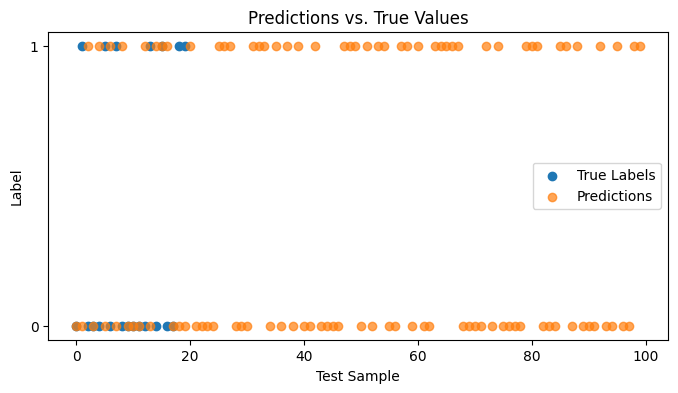

In [ ]:
# Real postprocessing after prediction (Business logic & Reporting)
# This cell prepares model outputs for business use, reporting, or integration.
import numpy as np
import pandas as pd

# Ensure X_test_preprocessed is a numpy array
if not isinstance(X_test_preprocessed, np.ndarray):
    X_test_preprocessed = np.array(X_test_preprocessed)

# Get predictions from the prediction tool
predictions = hgb_predict_tool.run(tool_input={
    "name": "my_hgbtree_model",
    "version": "1",
    "predict_table": "GENERATED_DATA_TBL",
    "features": features,
    "X_test": X_test_preprocessed,
    "key": "INDEX"
})

# Inverse transform test data to original scale
scaler = preprocessor.named_transformers_['num'].named_steps['scaler']
X_test_original = scaler.inverse_transform(X_test_preprocessed)

# Convert predictions output to dict if necessary
import json
if isinstance(predictions, str):
    predictions_dict = json.loads(predictions)
else:
    predictions_dict = predictions

pred_df = pd.DataFrame(predictions_dict["predictions"])
print(pred_df.head())  # Check column names

# Extract prediction values from correct column
if 'SCORE' in pred_df.columns:
    y_pred = pred_df['SCORE'].values
elif 'PREDICTION' in pred_df.columns:
    y_pred = pred_df['PREDICTION'].values
else:
    raise ValueError("Prediction column not found!")

min_len = min(len(y_test), len(y_pred))
results_df = pd.DataFrame(X_test_original[:min_len], columns=features)
results_df['True_Label'] = y_test[:min_len]
results_df['Prediction'] = y_pred[:min_len]

# Export results for reporting or further use
results_df.to_csv("prediction_results.csv", index=False)

print(results_df.head())

# Optional: Visualization as before
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.scatter(range(len(y_test)), y_test, label='True Labels')
plt.scatter(range(len(y_pred)), y_pred, label='Predictions', alpha=0.7)
plt.legend()
plt.title('Predictions vs. True Values')
plt.xlabel('Test Sample')
plt.ylabel('Label')
plt.show()

In [14]:
# 11. Set up LangChain integration for LLM-based agent
from langchain.agents import initialize_agent, AgentType
from gen_ai_hub.proxy.langchain import init_llm

llm = init_llm('gpt-4o', temperature=0.0, max_tokens=1800)
tools = [hgb_tool, hgb_predict_tool]
agent_chain = initialize_agent(
    tools,
    llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
)

/var/folders/s0/lpt_8gsd7mld2dfq18l7ryfm0000gn/T/ipykernel_22368/2874864960.py:7: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent_chain = initialize_agent(


In [15]:
# 12. Use agent for modeling task
agent_chain.invoke(f"""
    Train a Hybrid Gradient Boosting Tree model for synthetic diabetes prediction.

    Data:
    - Table: GENERATED_DATA_TBL
    - Target variable: {target}
    - Features: {', '.join(features)}

    Model Configuration:
    - Model name: my_hgbtree_model
    - Version: 1

    Note: The features are automatically generated numeric variables.
""")

{'input': '\n    Train a Hybrid Gradient Boosting Tree model for synthetic diabetes prediction.\n\n    Data:\n    - Table: GENERATED_DATA_TBL\n    - Target variable: V0\n    - Features: V1, V25, V38, V31, V37, V10, V26, V13, V20, V7, V4, V21\n\n    Model Configuration:\n    - Model name: my_hgbtree_model\n    - Version: 1\n\n    Note: The features are automatically generated numeric variables.\n',
 'output': 'The Hybrid Gradient Boosting Tree model named "my_hgbtree_model" has been successfully trained using the specified features and target variable from the "GENERATED_DATA_TBL" table. The model is saved as version 1. If you need further assistance or want to make predictions using this model, feel free to ask!'}

In [ ]:
# --- LangChain Agent Natural Language Test Cases ---

instruction = "Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'V0')."

print("Test: Train a model that ignores features with less than 5% variance.")
agent_chain.invoke(f"""
    {instruction}
    Train a Hybrid Gradient Boosting Tree model for diabetes prediction.
    Ignore features with less than 5% variance.
    Use max_depth=10 and n_estimators=200.
    Table: GENERATED_DATA_TBL
    Target: V0
    Features: {features}
    Key: INDEX
""")

print("Test: Predict outcomes for the following dataset but only return probabilities above 0.8.")
agent_chain.invoke(f"""
    {instruction}
    Predict outcomes for the table GENERATED_DATA_TBL.
    Only return probabilities above 0.8.
    Use model my_hgbtree_model version 1.
    Features: {features}
    Key: INDEX
""")

print("Test: Score the model accuracy on the test set and explain in one sentence what it means.")
agent_chain.invoke(f"""
    {instruction}
    Score the model accuracy on the test set.
    Explain in one sentence what the accuracy means.
    Use model my_hgbtree_model version 1.
    Table: GENERATED_DATA_TBL
    Target: V0
    Features: {features}
    Key: INDEX
""")

print("Test: Predict only for rows where feature V1 > 10.")
agent_chain.invoke(f"""
    {instruction}
    Predict only for rows in GENERATED_DATA_TBL where V1 > 10.
    Use model my_hgbtree_model version 1.
    Features: {features}
    Key: INDEX
""")

print("Test: Return feature importance sorted in descending order.")
agent_chain.invoke(f"""
    {instruction}
    Show feature importance for model my_hgbtree_model version 1, sorted descending.
    Table: GENERATED_DATA_TBL
    Target: V0
    Features: {features}
    Key: INDEX
""")

print("Test: Score the model and tell me if accuracy is above 0.9.")
agent_chain.invoke(f"""
    {instruction}
    Score the model on GENERATED_DATA_TBL.
    Tell me if accuracy is above 0.9.
    Use model my_hgbtree_model version 1.
    Target: V0
    Features: {features}
    Key: INDEX
""")

Test: Train a model that ignores features with less than 5% variance.
Test: Predict outcomes for the following dataset but only return probabilities above 0.8.
Test: Score the model accuracy on the test set and explain in one sentence what it means.
Test: Predict only for rows where feature V1 > 10.
Test: Return feature importance sorted in descending order.
Test: Score the model and tell me if accuracy is above 0.9.


{'input': "\n    Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'V0').\n    Score the model on GENERATED_DATA_TBL.\n    Tell me if accuracy is above 0.9.\n    Use model my_hgbtree_model version 1.\n    Target: V0\n    Features: ['V1', 'V25', 'V38', 'V31', 'V37', 'V10', 'V26', 'V13', 'V20', 'V7', 'V4', 'V21']\n    Key: INDEX\n",
 'output': 'The accuracy of the model is above 0.9.'}